# 06 · RNN: 시간에 펼친 MLP와 공유 파라미터

**질문:** `A, 빈칸, B`와 `B, 빈칸, A`는 기호 개수가 같습니다. 개수의 평균 대신 순서를 읽으려면 어떤 상태를 유지해야 할까요?

한 스텝의 수식 → 시간 반복 → BPTT → 순서 분류 → 시간별 기울기를 구현합니다. 03의 MLP backward와 04의 optimizer를 연결합니다. 본문만으로 새 커널에서 실행할 수 있습니다.

[그림 보조 파일](../../src/utils/architecture_plots.py) · [이전 CNN](05_cnn.ipynb) · [전체 경로](../../docs/CURRICULUM.md)

In [1]:
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/utils/plotting.py").is_file())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils.architecture_plots import plot_matrices, plot_curves
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· RNN 준비 완료")

NumPy 2.3.5 · RNN 준비 완료


## 1. 한 스텝은 두 입력을 받는 affine+tanh입니다

$X\in\mathbb R^{N\times T\times D}$에서 `X[:, t, :]`는 시각 $t$의 입력 $(N,D)$입니다. 상태 폭을 $H$로 놓으면
$$a_t=x_tW_x+h_{t-1}W_h+b,\qquad h_t=\tanh(a_t).$$

| 배열 | shape | 역할 |
|---|---|---|
| $W_x$ | $(D,H)$ | 현재 입력을 상태로 옮김 |
| $W_h$ | $(H,H)$ | 이전 상태를 다음 상태로 옮김 |
| $b$ | $(H,)$ | 모든 시각의 공통 편향 |
| $h_t$ | $(N,H)$ | 지금까지 읽은 내용의 계산 결과 |

상태는 데이터마다 달라지고, 파라미터는 데이터·시간에 공유됩니다. $T$가 길어져도 이 층의 파라미터 수는 $DH+H^2+H$로 같습니다. 아래 수학은 $t=1,\ldots,T$, Python은 `t=0,...,T-1`입니다. 캐시 `states[:,0]`에는 **초기 상태** $h_0$가 들어갑니다.

In [2]:
def rnn_forward(X, p, h0=None):
    N, T, _ = X.shape
    H = p["Wh"].shape[0]
    states = np.zeros((N, T + 1, H))
    if h0 is not None:
        states[:, 0] = h0
    for t in range(T):
        a = X[:, t] @ p["Wx"] + states[:, t] @ p["Wh"] + p["b"]
        states[:, t + 1] = np.tanh(a)
    return states[:, 1:], (X, states)

In [3]:
hand_p = {"Wx": np.array([[1.]]), "Wh": np.array([[0.5]]), "b": np.zeros(1)}
hand_X = np.array([[[1.], [0.]]])
hand_states, _ = rnn_forward(hand_X, hand_p)
h1 = np.tanh(1.)
h2 = np.tanh(0.5 * h1)
np.testing.assert_allclose(hand_states.ravel(), [h1, h2])
reverse_states, _ = rnn_forward(hand_X[:, ::-1], hand_p)
assert not np.allclose(hand_states[:, -1], reverse_states[:, -1])
print("[1,0] 상태:", hand_states.ravel(), "· [0,1] 상태:", reverse_states.ravel())

[1,0] 상태: [0.7616 0.3634] · [0,1] 상태: [0.     0.7616]


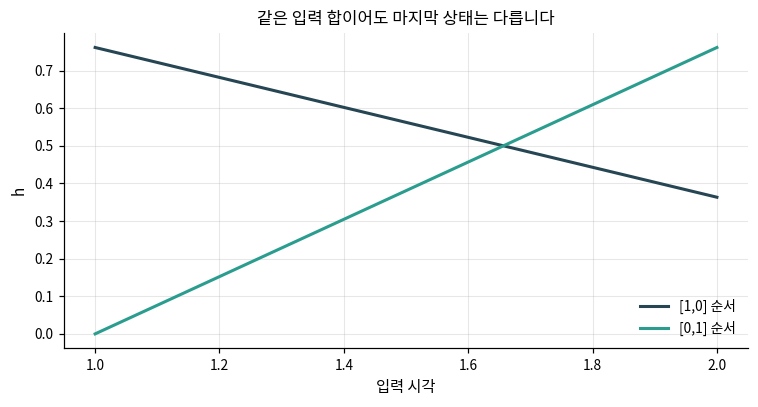

In [4]:
plot_curves([1, 2], {"[1,0] 순서": hand_states.ravel(), "[0,1] 순서": reverse_states.ravel()},
            title="같은 입력 합이어도 마지막 상태는 다릅니다", xlabel="입력 시각", ylabel="h")

## 2. 시간 역전파: 직접 온 기울기와 미래에서 온 기울기

손실이 각 시각의 $h_t$에 직접 의존할 수 있습니다. 그 직접 기여를 $g_t$라 두고, 미래의 상태 계산을 거쳐 돌아온 기여를 $r_t$라 두면
$$\delta_t=(g_t+r_t)\odot(1-h_t^2),\quad
r_{t-1}=\delta_tW_h^T,\quad dx_t=\delta_tW_x^T.$$
$$dW_x=\sum_t x_t^T\delta_t,\quad
 dW_h=\sum_t h_{t-1}^T\delta_t,\quad db=\sum_t\sum_n\delta_{t,n}.$$

`⊙`는 같은 위치끼리의 곱입니다. `1-h*h`는 tanh의 도함수입니다. 출력에서 들어온 `dH[:,t]`와 다음 시각에서 돌아온 `dh_next`는 **같은 상태 변수로 향하는 두 경로**이므로 더합니다. 공유 파라미터의 시간별 기여도 더합니다. 시간 역순 반복은 MLP의 층 역순 반복과 같은 chain rule입니다.

초기 상태가 0이어도 $dh_0$는 보통 0이 아닙니다. 초기 상태를 고정하면 그 미분을 업데이트에 쓰지 않을 뿐입니다.

In [5]:
def rnn_backward(dH, cache, p):
    X, states = cache
    N, T, _ = X.shape
    dX = np.zeros_like(X)
    dh_next = np.zeros_like(states[:, 0])
    grads = {key: np.zeros_like(value) for key, value in p.items()}
    for t in reversed(range(T)):
        dh = dH[:, t] + dh_next
        da = dh * (1 - states[:, t + 1] ** 2)
        grads["Wx"] += X[:, t].T @ da
        grads["Wh"] += states[:, t].T @ da
        grads["b"] += da.sum(axis=0)
        dX[:, t] = da @ p["Wx"].T
        dh_next = da @ p["Wh"].T
    return dX, dh_next, grads


def check_rnn_backward(candidate):
    rng = np.random.default_rng(61)
    errors = {}
    for T in [1, 4]:
        X = rng.normal(size=(2, T, 2)) * 0.3
        h0 = rng.normal(size=(2, 3)) * 0.2
        p = {"Wx": rng.normal(size=(2, 3)) * 0.2, "Wh": rng.normal(size=(3, 3)) * 0.2,
             "b": rng.normal(size=3) * 0.1}
        H, cache = rnn_forward(X, p, h0)
        G = rng.normal(size=H.shape)  # 마지막 시각만이 아니라 모든 시각에 손실을 연결
        dX, dh0, grads = candidate(G, cache, p)
        scalar = lambda: float(np.sum(rnn_forward(X, p, h0)[0] * G))
        for name, value, grad in [("X", X, dX), ("h0", h0, dh0), *[(k, v, grads[k]) for k, v in p.items()]]:
            error = rel_error(grad, numerical_gradient(scalar, value))
            assert np.isfinite(error) and error < 2e-6, (T, name, error)
            errors[f"T{T}/{name}"] = error
    return errors

In [6]:
rnn_errors = check_rnn_backward(rnn_backward)
print("RNN X·h0·모든 파라미터 최대 상대오차:", max(rnn_errors.values()))

RNN X·h0·모든 파라미터 최대 상대오차: 2.137166157521253e-10


### 왜 시간별 파라미터 미분을 평균내지 않습니까?

공유를 잠깐 풀어 $W_x^{(t)}$를 서로 독립인 변수라고 상상해 보세요. 모든 $W_x^{(t)}$를 하나의 $W_x$로 묶으면 chain rule에 의해 $dL/dW_x=\sum_t dL/dW_x^{(t)}$입니다. 평균 CE의 $1/N$은 CE backward에서 이미 적용됩니다. 시간 평균 목적을 별도로 정의했을 때에만 그 $1/T$가 추가됩니다.

## 3. 완성 실험: A가 B보다 먼저 나왔습니까?

기호는 `0=빈칸, 1=A, 2=B`이고 한 문장에는 A·B가 한 번씩 나옵니다. `np.eye(3)[tokens]`는 정수 인덱스로 단위행렬의 행을 골라 one-hot으로 바꿉니다. 결과 shape는 `(N,T,3)`입니다. 정수 기호 자체를 연속 실수처럼 미분하지 않습니다.

길이 6의 가능한 30개 배치를 모두 학습합니다. 각 입력의 기호 평균은 동일하므로 **기호 평균만 받은 모델**은 두 라벨을 구별할 수 없습니다. 길이 8의 56개 배치는 갱신에 쓰지 않고 길이가 달라진 경우를 확인합니다. 이를 임의의 장문에 대한 일반화로 해석하지 않습니다.

In [7]:
def order_data(T):
    tokens, labels = [], []
    for a in range(T):
        for b in range(T):
            if a == b:
                continue
            row = np.zeros(T, dtype=int)
            row[a], row[b] = 1, 2
            tokens.append(row)
            labels.append(int(a < b))
    tokens = np.array(tokens)
    return np.eye(3)[tokens], np.array(labels), tokens


def ce_loss(logits, y):
    z = logits - logits.max(axis=1, keepdims=True)
    logp = z - np.log(np.exp(z).sum(axis=1, keepdims=True))
    grad = np.exp(logp)
    grad[np.arange(len(y)), y] -= 1
    return -logp[np.arange(len(y)), y].mean(), grad / len(y)


def init_model(seed=62, width=12):
    rng = np.random.default_rng(seed)
    p = {"Wx": rng.normal(size=(3, width)) / np.sqrt(3),
         "Wh": rng.normal(size=(width, width)) / np.sqrt(width), "b": np.zeros(width)}
    head = {"W": rng.normal(size=(width, 2)) / np.sqrt(width), "b": np.zeros(2)}
    return p, head


def model_loss(X, y, p, head, backward_fn=rnn_backward):
    H, cache = rnn_forward(X, p)
    logits = H[:, -1] @ head["W"] + head["b"]
    loss, dlogits = ce_loss(logits, y)
    dhead = {"W": H[:, -1].T @ dlogits, "b": dlogits.sum(axis=0)}
    dH = np.zeros_like(H)
    dH[:, -1] = dlogits @ head["W"].T
    dX, dh0, grads = backward_fn(dH, cache, p)
    return loss, logits, grads, dhead, dX


def adam_step(p, grads, state, step, lr=0.02):
    for key in p:
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]
        v = 0.999 * v + 0.001 * grads[key] ** 2
        p[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)
        state[key] = (m, v)

In [8]:
X_train, y_train, tokens_train = order_data(6)
X_valid, y_valid, tokens_valid = order_data(8)
np.testing.assert_allclose(X_train.mean(axis=1), np.broadcast_to([4/6, 1/6, 1/6], (30, 3)))
print("학습", X_train.shape, "· 길이 변경 검증", X_valid.shape, "· 균형 라벨의 상수 예측 정확도 50%")

학습 (30, 6, 3) · 길이 변경 검증 (56, 8, 3) · 균형 라벨의 상수 예측 정확도 50%


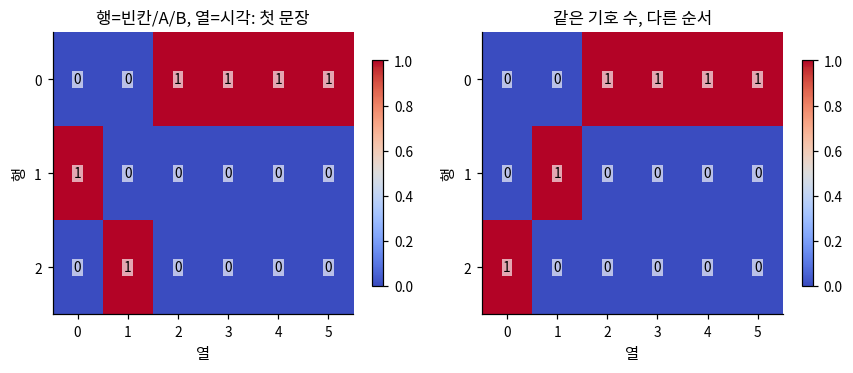

In [9]:
plot_matrices([X_train[0].T, X_train[5].T], ["행=빈칸/A/B, 열=시각: 첫 문장", "같은 기호 수, 다른 순서"])

분류 목적은 마지막 상태에 head를 붙인 CE입니다. RNN 자체는 손실함수가 아니므로 회귀 head와 MSE를 붙일 수도 있습니다. 이번 실험은 길이가 짧고 작아 full batch를 사용합니다.

폭주를 완화하기 위해 모든 학습 파라미터의 기울기를 하나로 본 norm으로 clip합니다.
$$g\leftarrow g\min(1,\tau/(\|g\|_2+10^{-12})).$$
순서 분류에서 clipping이 없어도 학습될 수 있지만, 이후 지연 기억 실험에 쓸 계산을 여기서 확인합니다.

In [10]:
p, head = init_model()
state_p = {k: (np.zeros_like(v), np.zeros_like(v)) for k, v in p.items()}
state_head = {k: (np.zeros_like(v), np.zeros_like(v)) for k, v in head.items()}
history = {"step": [], "train": [], "valid": []}
for step in range(401):
    loss, logits, grads, dhead, _ = model_loss(X_train, y_train, p, head)
    if step % 40 == 0:
        valid_loss, valid_logits, *_ = model_loss(X_valid, y_valid, p, head)
        history["step"].append(step)
        history["train"].append(loss)
        history["valid"].append(valid_loss)
    if step == 400:
        break
    norm = np.sqrt(sum(np.sum(g * g) for g in [*grads.values(), *dhead.values()]))
    scale = min(1., 1. / (norm + 1e-12))
    grads = {k: g * scale for k, g in grads.items()}
    dhead = {k: g * scale for k, g in dhead.items()}
    adam_step(p, grads, state_p, step + 1)
    adam_step(head, dhead, state_head, step + 1)
train_accuracy = np.mean(logits.argmax(axis=1) == y_train)
valid_accuracy = np.mean(valid_logits.argmax(axis=1) == y_valid)
print(f"학습 CE {history['train'][0]:.6f} → {history['train'][-1]:.6f}, 정확도 {train_accuracy:.1%}")
print(f"길이 8 검증 CE {history['valid'][-1]:.6f}, 정확도 {valid_accuracy:.1%}")
assert train_accuracy == 1. and history["train"][-1] < 0.05

학습 CE 0.676096 → 0.000036, 정확도 100.0%
길이 8 검증 CE 0.503527, 정확도 83.9%


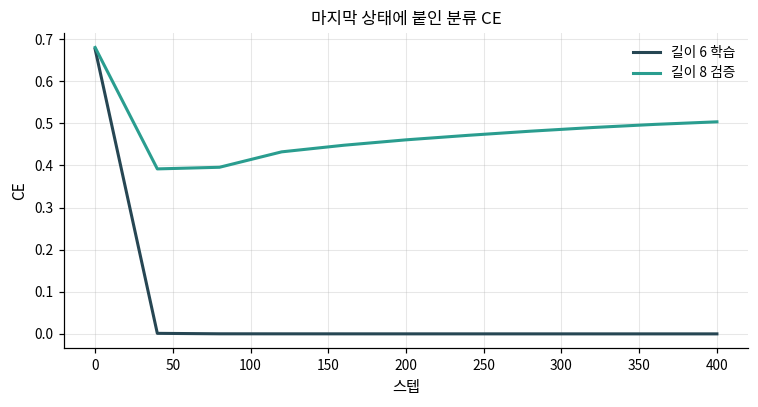

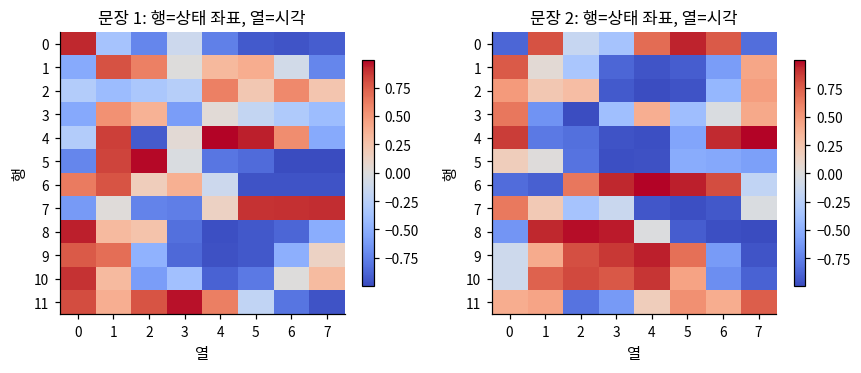

In [11]:
plot_curves(history["step"], {"길이 6 학습": history["train"], "길이 8 검증": history["valid"]},
            title="마지막 상태에 붙인 분류 CE", ylabel="CE")
selected_states, _ = rnn_forward(X_valid[[0, 7]], p)
plot_matrices([selected_states[0].T, selected_states[1].T],
              ["문장 1: 행=상태 좌표, 열=시각", "문장 2: 행=상태 좌표, 열=시각"], annotate=False)

상태의 각 좌표가 사람이 붙인 특정 의미를 갖는다고 단정할 수는 없습니다. 그림에서 확인하는 것은 **같은 파라미터가 입력 순서에 따라 다른 상태 경로를 만든다**는 사실입니다.

## 4. 시간 미분의 곱: 사라지거나 커지는 이유

스칼라 RNN에서는
$$\frac{\partial h_T}{\partial h_0}=\prod_{t=1}^T w_h(1-h_t^2).$$
다차원에서는 이 값들이 Jacobian 행렬의 곱으로 바뀝니다. $|w_h|$ 하나만 보고 일반 RNN의 전체 기울기를 판정할 수는 없습니다. tanh의 포화와 행렬 방향도 영향을 줍니다.

같은 조건에서 $\partial h_T/\partial x_t=w_xw_h^{T-t}$입니다. 입력 x_t는 먼저 w_x를 거친 뒤 남은 T-t개의 상태 연결을 통과하기 때문입니다. 아래 그림은 이 입력별 미분이고, 검산 셀은 h0의 미분도 함께 확인합니다.

아래는 입력·상태가 정확히 0인 특별한 경우입니다. tanh의 도함수가 1이므로 $w_h^T$가 그대로 나옵니다. `np.linalg.norm`은 제곱합의 제곱근을 계산합니다. 로그 y축은 여러 자릿수의 변화를 한 그림에 표시합니다.

In [12]:
T = 25
temporal_gradients = {}
for weight in [0.7, 1.0, 1.2]:
    probe = {"Wx": np.ones((1, 1)), "Wh": np.array([[weight]]), "b": np.zeros(1)}
    H, cache = rnn_forward(np.zeros((1, T, 1)), probe)
    G = np.zeros_like(H)
    G[:, -1] = 1
    dX, dh0, _ = rnn_backward(G, cache, probe)
    np.testing.assert_allclose(dh0.item(), weight ** T, rtol=1e-12)
    temporal_gradients[f"Wh={weight}"] = np.abs(dX[0, :, 0])
print("스칼라 h0 미분 = Wh의 T제곱 검산 통과")

스칼라 h0 미분 = Wh의 T제곱 검산 통과


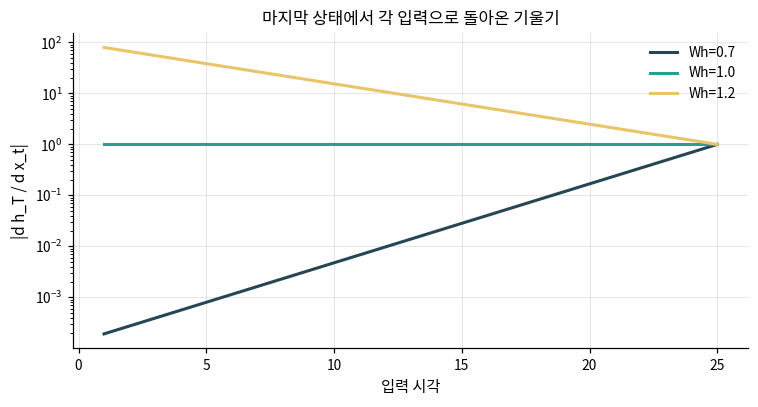

In [13]:
plot_curves(np.arange(1, T + 1), temporal_gradients, title="마지막 상태에서 각 입력으로 돌아온 기울기",
            xlabel="입력 시각", ylabel="|d h_T / d x_t|", logy=True)

clipping은 큰 기울기의 크기를 제한합니다. 이미 사라진 과거 기울기를 복원하지는 않습니다. 이 차이가 다음 LSTM·GRU에서 덧셈 경로와 게이트를 살펴보는 이유입니다.

## 5. 직접 변형하고 검사하기

새 코드 셀(`Esc`, `B`)에 `my_rnn_backward(dH, cache, p)`를 작성하고 `check_rnn_backward(my_rnn_backward)`를 호출하세요. 검사기는 초기 상태가 0이 아닌 경우, 길이 1·4, **모든 시각에서 직접 온 상류 기울기**를 사용합니다.

1. `dh_next`를 빼면 어떤 경로를 끊습니까? 아래 의도적 오답이 거부되는지 확인하세요.
2. 마지막 상태만 쓰는 손실을 $L=\frac12\sum_t\|h_t\|^2$로 바꾸면 상류 기울기는 `dH=H`입니다. 자신의 backward와 수치미분을 비교하세요.
3. 학습 길이를 6→4로 바꾸고 길이 8에서 다시 평가하세요. 학습 파라미터 수와 길이 밖 성능을 따로 기록하세요.

**truncated BPTT**는 일부 시간 경로의 미분을 의도적으로 끊는 근사입니다. 전체 BPTT의 수치미분을 통과할 구현과는 목적이 다르므로, 아래 오답을 그 이름으로 정답 처리하지 않습니다.

In [14]:
def wrong_no_future(dH, cache, p):
    X, states = cache
    grads = {k: np.zeros_like(v) for k, v in p.items()}
    dX = np.zeros_like(X)
    for t in reversed(range(X.shape[1])):
        da = dH[:, t] * (1 - states[:, t + 1] ** 2)  # 미래에서 돌아오는 항 누락
        grads["Wx"] += X[:, t].T @ da
        grads["Wh"] += states[:, t].T @ da
        grads["b"] += da.sum(axis=0)
        dX[:, t] = da @ p["Wx"].T
    return dX, np.zeros_like(states[:, 0]), grads

In [15]:
try:
    check_rnn_backward(wrong_no_future)
except AssertionError:
    print("의도적 오답 검출: 미래 경로와 h0 미분 누락")
else:
    raise AssertionError("검사기가 오답을 놓쳤습니다")
probe_X = np.random.default_rng(66).normal(size=(2, 4, 3)) * 0.2
probe_H, probe_cache = rnn_forward(probe_X, p)
probe_dX, _, _ = rnn_backward(probe_H, probe_cache, p)
numeric = numerical_gradient(lambda: float(0.5 * np.sum(rnn_forward(probe_X, p)[0] ** 2)), probe_X)
np.testing.assert_allclose(probe_dX, numeric, atol=1e-7, rtol=1e-5)
print("모든 시각의 제곱 손실 변형 통과 — 자신의 backward로도 같은 셀을 실행하세요")

의도적 오답 검출: 미래 경로와 h0 미분 누락
모든 시각의 제곱 손실 변형 통과 — 자신의 backward로도 같은 셀을 실행하세요


### 준비도 확인

- **설명:** 상태와 파라미터의 차이, 순서가 계산에 들어가는 위치를 설명할 수 있습니까?
- **수식:** 직접 기울기와 미래 경로를 더하고, 공유 가중치의 시간별 미분을 합할 수 있습니까?
- **구현:** 캐시의 초기 상태와 출력 시각 인덱스를 구별하며 dX·dh0·dW를 구현할 수 있습니까?
- **변형:** 모든 시각의 손실과 길이가 달라진 입력을 처리하고 기울기 변화의 한계를 해석할 수 있습니까?

RNN의 상태 갱신과 시퀀스 확률의 연결은 [Cho 등, 2014의 2.1절](https://arxiv.org/abs/1406.1078)을 참고할 수 있습니다. 여기서는 기본 tanh RNN의 지도 분류에 집중했습니다.

다음은 [07 LSTM·GRU](07_lstm_gru.ipynb)입니다.